# Week 7: Model Evaluation 🔍
# Tutorial

In the previous week, we trained a model using the training data and improved the model by tuning hyperparameters. This week we will use the test data to do a final evaluation of how well our model performs on unseen data. This is the final step of the pipeline.

We will discuss the following topics and how to use the evaluation metrics in sklearn:
1. Generalization
2. Underfitting/overfitting
3. Evaluation metrics
    * Accuracy
    * Confusion Matrix
    * Precision & Recall
    * F1-score

We will then evaluate our trained breast cancer model using our test set and interpret the results.

First, run the cell below to load a trained model and the dataset (split into train and test). This model has been trained similar to your work in the week 6 tutorial.

In [18]:
import pandas as pd
import numpy as np

# machine learning
from sklearn.model_selection import train_test_split
# model loading
import pickle

df = pd.read_csv('bc_data.csv', index_col=0)

# Data cleaning
# remove the 'Unnamed: 32' column
df = df.drop('Unnamed: 32', axis=1)

# encode target feature to binary class and split target/predictor vars
y = df["diagnosis"].map({"B" : 0, "M" : 1})
x = df.drop("diagnosis", axis = 1)

# drop all "worst" columns
cols = ['radius_worst', 
        'texture_worst', 
        'perimeter_worst', 
        'area_worst', 
        'smoothness_worst', 
        'compactness_worst', 
        'concavity_worst',
        'concave points_worst', 
        'symmetry_worst', 
        'fractal_dimension_worst']
x = x.drop(cols, axis=1)

# drop perimeter and area (keep radius)
cols = ['perimeter_mean',
        'perimeter_se', 
        'area_mean', 
        'area_se']
x = x.drop(cols, axis=1)

# Data splitting
# train (70%), val (15%), test (15%)
# val set not needed in this module, but kept for consistency
# random_state seed is the same as week 6; resulting sets should be the same
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_ratio, random_state=40)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=val_ratio/(train_ratio + val_ratio), random_state=40)

# Load a trained model
with open('bc_model.pkl', 'rb') as file:
    model = pickle.load(file)

/Users/skim4/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator SGDClassifier from version 1.3.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# Generalization

When we talk about model performance, we want to know how well a model <span style="background-color: #AFEEEE">**generalizes**</span>. This measures a model's ability to perform well on new, unseen data. Remember that in the beginning of our pipeline, we created hold-out data that we never show the model during training. We will use this test data in this evaluation stage.

If a model doesn't perform well during training and does not learn the important features, this is called <span style="background-color: #AFEEEE">**underfitting**</span>. The model you selected may be too simple to capture the level of complexity within the data.

If a model performs well during training but poorly on unseen data, this is called <span style="background-color: #AFEEEE">**overfitting**</span>. While the model may have learned important patterns of the training data set, it may have also picked up <span style="background-color: #AFEEEE">**noise**</span> as part of the learned patterns, which will not be seen in the test set.

**Noise**: irrelevant data in the dataset that is not part of the useful pattern that needs to be learned. Outliers, errors, or inconsistencies in the dataset are examples of noise. We say that a dataset is **noisy** if it includes many such datapoints. 

|  | Definition | How to detect |
| --- | --- | --- |
| **Underfitting** | a model is not able to capture the useful/important patterns in the dataset. | Poor performance on the training set | 
| **Overfitting** | a model performs poorly on unseen test data, even though it performed well during training. | Great performance on the training set, but poor performance on the test set |

When the model performs well on the training set and the test set, we say that it is a **good fit** and **generalizes** well. This means the model has learned from the training set well enough to apply in the general case, to new data it has not seen before.

**Generalization**: a model's ability to adapt to and perform well on new, unseen data.
A model generalizes well if it performs well on unseen data (i.e. a test set)


To see the differences between these 3 cases, consider the three graphs below. Each attempts to draw a line of best fit through the points using different order polynomials. The green curve shows the pattern represented by the data points. On the left is the most simple function, a first-order polynomial (y = m*x + b). This is essentially a straight line. As you can see, it does not capture the pattern entirely; this is underfitting. On the right is a more complex function, a ninth-order polynomial. This curve passes through every point, but it does not capture the actual pattern demonstrated by the green line because it is learning noise in the dataset; this is a case of overfitting. This model would not generalize well. Lastly, the graph in the middle uses a model somewhere in between, a third-order polynomial, and achieves a good fit.

<img src="overgoodunder.png" style="width: 1000px;"/>

*image: https://machine-learning.paperspace.com/wiki/overfitting-vs-underfitting

In the above example, we showed how varying model complexity can lead to underfitting/overfitting. However, there are more factors that could lead to these cases, and therefore many techniques to correct for them. If the model is underfitting, we could try to correct for it by choosing a more complex model, increasing training data, increasing the number of features,increasing the number of training iterations (epochs), or cleaning the data better. If the model is overfitting, we can try reducing the model complexity, using early stopping (stop training early), and increasing training data. As you can see, underfitting and overfitting are concepts that are difficult to detect and even define. We will not discuss ways to deal with underfitting and overfitting in this module, but the underfitting/overfitting problem is an important part of model evaluation and improvement that will be revisited in the future.

## Generating model predictions

First we need to get the trained model's predictions. Our evaluation metrics will need both the classification (0/1) labels and prediction probabilities. We can do this using the **predict()** function, which can be accessed and called on sklearn model objects. The model that you trained in week 6 is an object of the SGDClassifier class, so this function is available on your model.  

| Function | Input Parameters | Output | Syntax |
| --- | --- | --- | --- |
| predict() | array of input data points | predicted classifications (0's and 1's) corresponding to each input data point. For example, [0, 1, 1, 0, 0, 0, 1, 0, ... , 1] | model.predict(input_testset) |

Documentation for SGDClassifier: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html
Scroll down to "methods" to see the functions that can be called on objects of this class.

<span style="background-color: #FFD700">**Q1. Complete the code below to call predict() on the model, using your test set inputs.**</span>

In [19]:
# your test set is saved in variables x_test and y_test.

# Prediction
preds = #TODO: complete this line

print(preds)

[0 1 0 1 1 0 1 0 1 0 1 1 1 0 1 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0 1 1 0 1 1 0
 1 0 1 1 0 0 0 1 1 0 1 1 0 1 0 0 0 1 0 1 1 1 0 1 1 0 0 0 1 1 1 0 0 0 1 1 0
 1 1 1 0 0 0 0 0 1 1 1 1]


## Using evaluation metrics

In the pre-module we talked about 4 metrics we can calculate: accuracy, precision, recall, and the f1-score (along with the confusion matrix). 

To get these results using sklearn, we need to import some functions from sklearn.metrics.

<span style="background-color: #FFD700">**Run the code below to import the libaries for model metrics.**</span>

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

### Generating the Confusion Matrix

Let's generate the confusion matrix first, using the ```confusion_matrix()``` function provided in scikit-learn.

In this table, y_true = array of input data points and y_pred = array of predicted labels.

| Function | Input parameters | Output | Syntax |
| --- | --- | --- | --- |
| confusion_matrix() | y_true, y_pred | a confusion matrix represented as a 2D array | confusion_matrix(y_test, preds) |

<span style="background-color: #FFD700">**Q2. Complete the code below to generatre the confusion matrix.**</span>

In [21]:

conf =  #TODO: complete this line

### Confusion Matrix Display
Right now if we print the confusion matrix we get:

In [22]:
print(f"\nConfusion matrix:\n",conf)


Confusion matrix:
 [[40 14]
 [ 0 32]]


For better, clearer visualization with proper axis labels, we can use the ConfusionMatrixDisplay object from sklearn. 

First we have to import a function from sklearn.metrics, like we did for all the other metrics. The ConfusionMatrixDisplay() function creates an object of the ConfusionMatrixDisplay class, and this object can display/plot the confusion matrix.

A little explanation on the input parameters to this function:
* confusion_matrix: a confusion matrix object (from sklearn ```confusion_matrix```)
* display_labels: an array of axis labels. You can obtain them from your model with ```model.classes_```

| Function | Input parameters | Output | Syntax |
| --- | --- | --- | --- |
| ConfusionMatrixDisplay() | confusion_matrix, display_labels | a display object for confusion matrix. | ConfusionMatrixDisplay(confusion_matrix, display_labels) |

Finally, calling **plot()** on your newly created confusion matrix display object will plot the actual display. 

Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html

<span style="background-color: #FFD700">**Q3. Complete the code below to create a confusion matrix display.**</span>

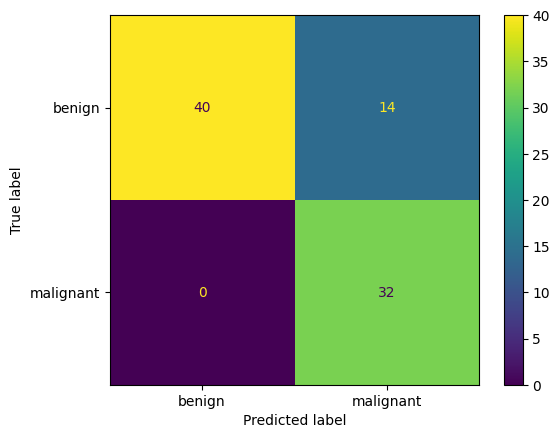

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
labels = np.where(model.classes_, 'malignant', 'benign')


display = # TODO: complete this line


display.plot()

<span style="background-color: #FFD700">**Answer the questions below.**</span>

**Q4. Identify the number of FP, FN, TP, and TN from the confusion matrix of the breast cancer detection model. Malignant is positive.** 

<span style="background-color: #FFD700">**Write your answer here**</span>

**Q5. State the ratio of actual positives to actual negatives. Is this dataset balanced?**

<span style="background-color: #FFD700">**Write your answer here**</span>

**Q6. Using what you learned in the pre-module, calculate the accuracy, precision, recall, and f1-score for the breast cancer model based on the confusion matrix.**

<span style="background-color: #FFD700">**Write your answer here**</span>

## Generating Accuracy, Precision, Recall, F1-Score

Here is a summary of the sklearn functions for the metrics we covered in the pre-module, as well as their input parameters, output, and syntax. Note that there are additional optional input parameters than listed here, but for this particular binary classification problem we do not need them. We have only listed the required parameters for each funciton. 

In this table, y_true = array of input data points and y_pred = array of predicted labels.

| Function | Input parameters | Output | Syntax |
| --- | --- | --- | --- |
| accuracy_score() | y_true, y_pred | accuracy (decimal) | accuracy_score(y_test, preds) |
| precision_score() | y_true, y_pred | precision (decimal) | precision_score(y_test, preds) | 
| recall_score() | y_true, y_pred | recall (decimal) | recall_score(y_test, preds) | 
| f1_score() | y_true, y_pred | f1-score (decimal) | f1_score(y_test, preds) | 

<span style="background-color: #FFD700">**Q7. Complete the code below to get each metric and save them to the given variables.**</span>


In [24]:
# Evaluation metrics
acc = #TODO: complete this line
precision =  #TODO: complete this line
recall = #TODO: complete this line
f1 = #TODO: complete this line

Let's print all our results. **Run the code below**.

In [25]:
eval = pd.Series({
    "Accuracy": acc,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
})

print(f"Model: LogisticRegression")
print(f"\nEvaluation metrics:\n",eval)

Model: LogisticRegression

Evaluation metrics:
 Accuracy     0.837209
Precision    0.695652
Recall       1.000000
F1-Score     0.820513
dtype: float64


Look at the generated evaluation results for the 4 metrics above. Compare them with your hand-calculated results in question 3- they should be the same. You can use the scikit-learn-generated values to check your work.

<span style="background-color: #FFD700">**Answer the questions in the markdown cell below.**</span>

**Q8. There is no universal threshold for what constitutes a "good model". However, your colleagues at the Breast Cancer Institute have unanimously decided that a model with an f1-score of 0.8 and above will suffice. They believe that using the f1-score to evaluate the model is the best approach, since it combines precision and recall and the dataset is imbalanced. They are not considering using any other metrics at the moment.** 

**You disagree with your colleagues on this decision. How would you evaluate the performance differently, and why? What information might you need (from physicians, medical researchers etc.) in order to make a recommendation?**

<span style="background-color: #FFD700">**Write your answer here**</span>

## Graded exercise (5 marks)

**GQ1. (2 marks) Suppose that upon evaluating your model, you find that the accuracy is very low (around 60%). However, the accuracy during training was very good (around 95%). What do you call this phenomenon, and how would you try to correct it? List at least two methods discussed in this module.**

<span style="background-color: #FFD700">**Write your answer here**</span>

**GQ2. (2 marks) Suppose that your model has an accuracy of 62% during training, using a logistic regression model and 200 training samples. After obtaining more samples for your dataset, you retrain the model with 400 training samples, but the accuracy only goes up to 66%. What do you call this phenomenon, and how would you try to correct it? List at least two methods discussed in this module.**

<span style="background-color: #FFD700">**Write your answer here**</span>

**GQ3. (1 mark) Say that one of your colleagues has trained a different model. Their evaluation results look like this:**

Colleague's evaluation results:
* Accuracy     0.868421
* Precision    0.900000
* Recall       0.692308
* F1-Score     0.782609

And your evaluation results look like this:
* Accuracy     0.837209
* Precision    0.695652
* Recall       1.000000
* F1-Score     0.820513

**Assume that the dataset is imbalanced (more benign cells). Your colleague says that your model performs better than theirs. Describe two reasons, seen in the two evaluation results, to support this claim.**

<span style="background-color: #FFD700">**Write your answer here**</span>

## Conclusion

Let's go back to our motivation-- we set out to find out how well a machine learning model could be used to predict which cancer cells are benign or malignant, as a form of early diagnosis to improve patient care. What did we learn? Based on our evaluation, the logistic regression model we trained on this dataset shows potential to be useful as a tool to aid physicians in their diagnosis; an f1-score of 0.82 is generally considered good. However, more information from stakeholders might be needed to quantify exactly how "good" the model has to be for it to be feasible in a medical setting. Realizing that these decisions might require expert opinions and interdisciplinary collaboration, you call for a meeting with machine learning researchers, biologists, physicians, and your colleagues at the Canadian Cancer society. You organize your results and learnings into a report, and head off to the meeting with valuable information that could leave a lasting impact on healthcare.


## Recap of ML Pipeline

<img src="image-8.png" alt="Drawing" style="width: 650px;"/>
<img src="image-9.png" alt="Drawing" style="width: 650px;"/>
<img src="image-11.png" alt="Drawing" style="width: 650px;"/>
<img src="image-12.png" alt="Drawing" style="width: 650px;"/>

Congratulations! You are now able to identify what happens in each stage of a machine learning pipeline and how each stage works. 